In [1]:
import pandas as pd
df = pd.read_csv('/content/reddit_preprocessing.csv')
df

,clean_comment,category,words_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0
...,...,...,...,...,...,...
36788,jesus,0,1,0,5,0
36789,kya bhai pure saal chutiya banaya modi aur jab...,1,19,0,99,0
36790,downvote karna tha par upvote hogaya,0,6,0,36,0
36791,haha nice,1,2,0,9,0


In [2]:
df['clean_comment'].isna().sum()
df = df.dropna(subset=['clean_comment'])

In [3]:
X = df['clean_comment']
y = df['category']

# BoW Vectorizer

In [4]:
# boW verctorization
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000,stop_words='english',
    ngram_range=(1,2))

X = bow.fit_transform(X)



# Train Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Model Training

In [6]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score

model = MultinomialNB(alpha=.5)
scores = cross_val_score(model, X_train, y_train, cv=5)
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

model.fit(X_train, y_train)

Cross-validation scores: [0.65001705 0.65513126 0.64728946 0.65768837 0.66462063]
Mean accuracy: 0.6549493563119967


MultinomialNB(alpha=0.5)

# Classification Report

In [7]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6616664393836084
              precision    recall  f1-score   support

          -1       0.63      0.59      0.61      1650
           0       0.78      0.53      0.63      2529
           1       0.62      0.81      0.70      3154

    accuracy                           0.66      7333
   macro avg       0.68      0.64      0.65      7333
weighted avg       0.68      0.66      0.66      7333



# Confusion Matrix

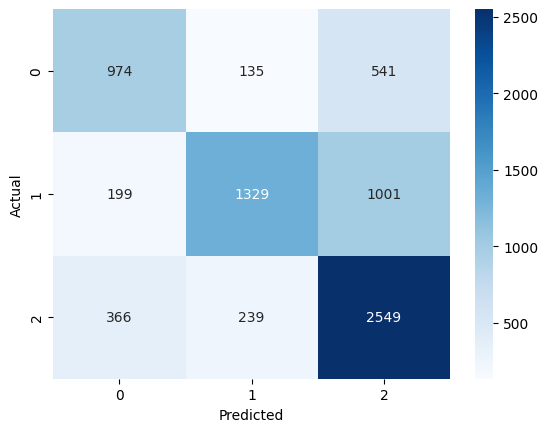

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [10]:
import pickle
pickle.dump(model, open("nb_model.pkl", "wb"))
pickle.dump(bow, open("bow_vectorizer.pkl", "wb"))